<a href="https://colab.research.google.com/github/cu24250113-priyashi/Computer_Vision/blob/main/LABSHEET1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
%pip install Pillow

Original Image:


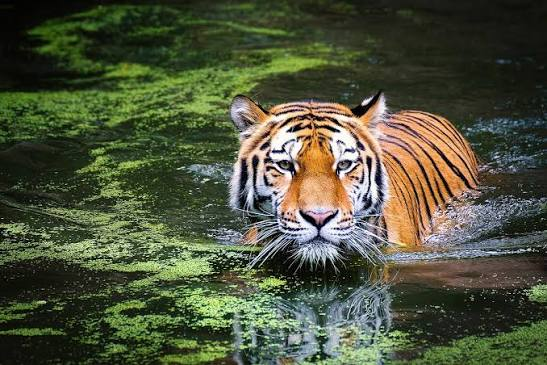

In [9]:
import numpy as np
image_path = "/content/tiger.jpeg"
img = cv2.imread(image_path, -1)
print('Original Image:')
cv2_imshow(img)

### 1. Build a tool that loads any images format and dispaly its dimensions, number of channels, file size and data type .

In [29]:
print(f"Image Dimensions (Height, Width, Channels): {img.shape}")

if len(img.shape) == 3:
    print(f"Number of Channels: {img.shape[2]}")
else:
    print("Number of Channels: 1 (Grayscale image)")

file_size = os.path.getsize(image_path)
print(f"File Size: {file_size} bytes")

print(f"Data Type: {img.dtype}")

Image Dimensions (Height, Width, Channels): (365, 547, 3)
Number of Channels: 3
File Size: 53759 bytes
Data Type: uint8


### 2. Create a Program that reads color image , convert it to grayscale and saves both versions side by side for visual comparsion

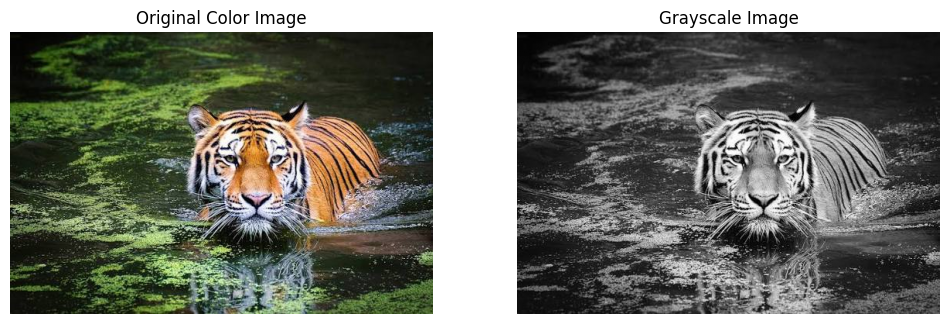

In [30]:

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.show()


### 3. image format converter that takes one input image and export it as jpg, png, and bmp , then compares the resulting file sizes.

In [32]:
def convert_and_compare_formats(image, base_name="output_image"):
    output_formats = {
        'jpg': f'{base_name}.jpg',
        'png': f'{base_name}.png',
        'bmp': f'{base_name}.bmp'
    }

    file_sizes = {}

    print("Converting and saving images...")
    for fmt, filename in output_formats.items():
        if fmt == 'jpg':
            cv2.imwrite(filename, image, [cv2.IMWRITE_JPEG_QUALITY, 95])
        else:
            cv2.imwrite(filename, image)

        size = os.path.getsize(filename)
        file_sizes[fmt] = size
        print(f"  Saved {filename} (Format: {fmt.upper()}, Size: {size} bytes)")

    print("\n--- File Size Comparison ---")
    for fmt, size in file_sizes.items():
        print(f"  {fmt.upper()}: {size} bytes")
    print("--------------------------")
convert_and_compare_formats(img, base_name="converted_image")

Converting and saving images...
  Saved converted_image.jpg (Format: JPG, Size: 106118 bytes)
  Saved converted_image.png (Format: PNG, Size: 434206 bytes)
  Saved converted_image.bmp (Format: BMP, Size: 600114 bytes)

--- File Size Comparison ---
  JPG: 106118 bytes
  PNG: 434206 bytes
  BMP: 600114 bytes
--------------------------


### 4. A photo negative generater that computes and dispaly the complement of an uploaded images

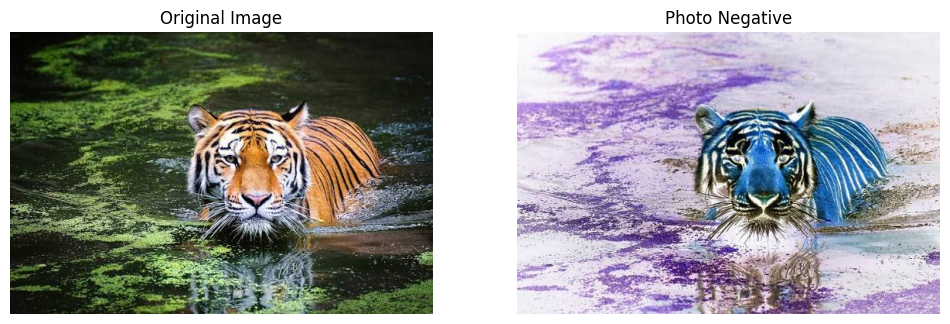

In [33]:

negative_img = cv2.bitwise_not(img)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(negative_img, cv2.COLOR_BGR2RGB))
plt.title('Photo Negative')
plt.axis('off')

plt.show()

### 5. Batch images resizer that reads multiple images from folder and saves resized copies while preserving aspacts ratio

In [35]:
def batch_resize_images(input_dir, output_dir, target_width=None, target_height=None) :
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    if target_width is None and target_height is None:
        print("Error: Either target_width or target_height must be provided.")
        return

    print(f"Processing images in '{input_dir}'...")
    for filename in os.listdir(input_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp')):
            image_path = os.path.join(input_dir, filename)
            img = cv2.imread(image_path)

            if img is None:
                print(f"Warning: Could not read image {filename}. Skipping.")
                continue

            h, w = img.shape[:2]

            if target_width is None:
                ratio = target_height / h
                new_w = int(w * ratio)
                new_h = target_height
            elif target_height is None:
                ratio = target_width / w
                new_h = int(h * ratio)
                new_w = target_width
            else:
                ratio_w = target_width / w
                ratio_h = target_height / h
                ratio = min(ratio_w, ratio_h)
                new_w = int(w * ratio)
                new_h = int(h * ratio)

            resized_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, resized_img)
            print(f"  Resized '{filename}' to {new_w}x{new_h} and saved to '{output_path}'")

    print("Batch resizing complete.")

input_folder = 'input_images_for_resize'
output_folder = 'resized_images'

if not os.path.exists(input_folder):
    os.makedirs(input_folder)

if os.path.exists(image_path):
    import shutil
    shutil.copy(image_path, os.path.join(input_folder, os.path.basename(image_path)))
    print(f"Copied '{os.path.basename(image_path)}' to '{input_folder}'")
else:
    print(f"Error: Image at '{image_path}' not found. Please ensure it exists.")

batch_resize_images(input_folder, output_folder, target_width=200)

Copied 'tiger.jpeg' to 'input_images_for_resize'
Processing images in 'input_images_for_resize'...
  Resized 'tiger.jpeg' to 200x133 and saved to 'resized_images/tiger.jpeg'
Batch resizing complete.


### 6. Crop a user-specified region of interest from an image and save it as a separate file.

Attempting to crop region: x=150, y=100, width=200, height=150
Cropped image saved to 'tiger_cropped.jpg'
Cropped Image:


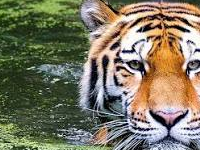

In [36]:
def crop_image_region(image, x, y, width, height, output_path='cropped_image.jpg') :
    img_height, img_width = image.shape[:2]
    x = max(0, x)
    y = max(0, y)
    width = min(width, img_width - x)
    height = min(height, img_height - y)

    if width <= 0 or height <= 0:
        print("Error: Invalid crop region. Width and height must be positive.")
        return

    cropped_image = image[y:y+height, x:x+width]

    cv2.imwrite(output_path, cropped_image)
    print(f"Cropped image saved to '{output_path}'")
    print("Cropped Image:")
    cv2_imshow(cropped_image)
crop_x = 150
crop_y = 100
crop_width = 200
crop_height = 150

print(f"Attempting to crop region: x={crop_x}, y={crop_y}, width={crop_width}, height={crop_height}")

crop_image_region(img, crop_x, crop_y, crop_width, crop_height, output_path='tiger_cropped.jpg')


### 7. Split an image into its individual Red, Green, Blue channels, reconstruct it, and verify pixel-level accuracy.

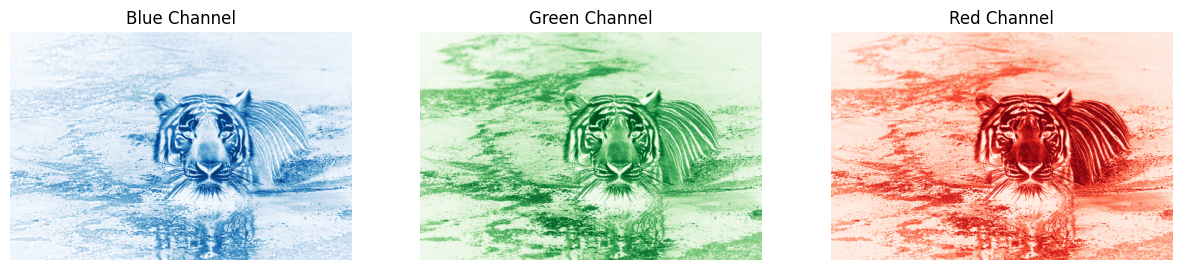

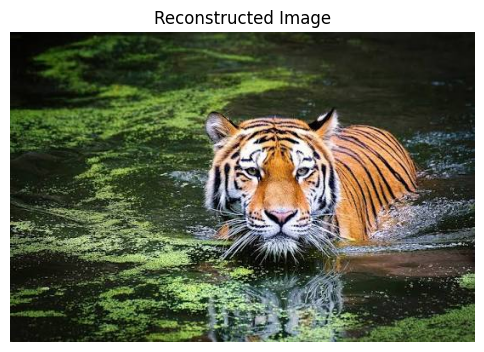

Are the original and reconstructed images pixel-identical? True


In [37]:
(b, g, r) = cv2.split(img)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(b, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(g, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(r, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.show()
reconstructed_img = cv2.merge([b, g, r])

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(reconstructed_img, cv2.COLOR_BGR2RGB))
plt.title('Reconstructed Image')
plt.axis('off')
plt.show()
is_identical = np.array_equal(img, reconstructed_img)

print(f"Are the original and reconstructed images pixel-identical? {is_identical}")

if not is_identical:
    diff = cv2.absdiff(img, reconstructed_img)
    total_diff = np.sum(diff)
    print(f"Total absolute difference between images: {total_diff}")
    # Optionally display the difference image for visual inspection
    # plt.figure(figsize=(6,6))
    # plt.imshow(diff)
    # plt.title('Difference Image')
    # plt.axis('off')
    # plt.show()


### 8. Create a watermarking utility that overlays a text on an image and saves it.

Watermarked image saved to 'tiger_watermarked.jpg'
Watermarked Image:


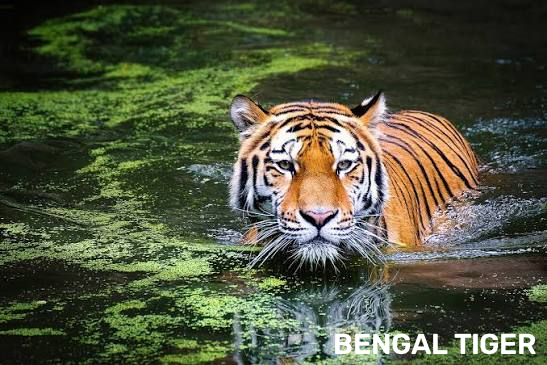

In [44]:
def add_text_watermark(image, text, position=(10, 30), font=cv2.FONT_HERSHEY_SIMPLEX, font_scale=1, color=(0, 255, 255), thickness=2, output_path='watermarked_image.jpg'):
    watermarked_img = image.copy()

    cv2.putText(watermarked_img, text, position, font, font_scale, color, thickness, cv2.LINE_AA)

    cv2.imwrite(output_path, watermarked_img)
    print(f"Watermarked image saved to '{output_path}'")

    print("Watermarked Image:")
    cv2_imshow(watermarked_img)


watermark_text = "BENGAL TIGER"
(text_width, text_height), baseline = cv2.getTextSize(watermark_text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
img_height, img_width = img.shape[:2]

position_x = img_width - text_width - 10
position_y = img_height - baseline - 10

add_text_watermark(
    img,
    watermark_text,
    position=(position_x, position_y),
    color=(255, 255, 255),
    font_scale=1,
    thickness=2,
    output_path='tiger_watermarked.jpg'
)


### 9. Rotate and flip an image by user-defined angles and directions, saving all transformation versions.

--- Original Image ---


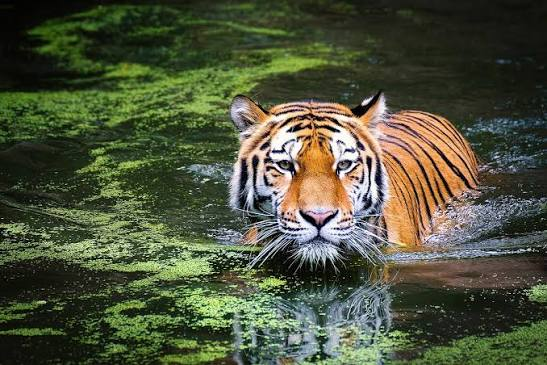

Saved transformed image to 'tiger_rotated_90deg.jpg'
Transformed Image (Rotated 90Deg):


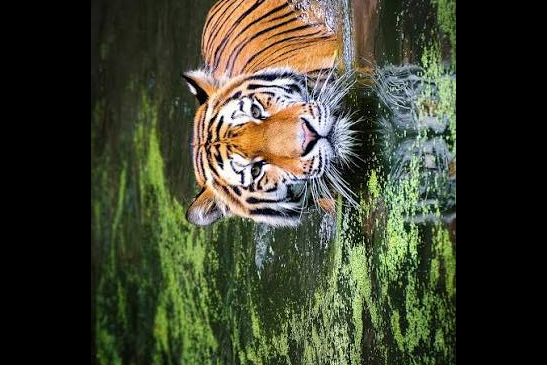

Saved transformed image to 'tiger_rotated_180deg.jpg'
Transformed Image (Rotated 180Deg):


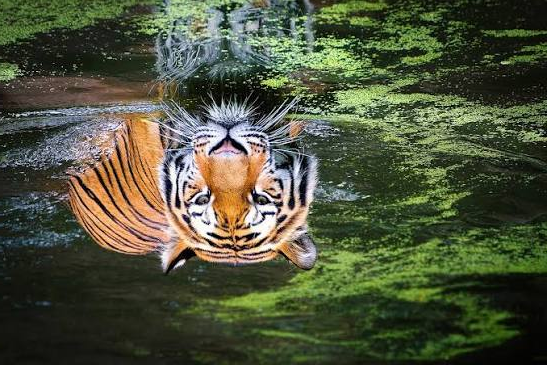

Saved transformed image to 'tiger_horizontal_flip.jpg'
Transformed Image (Horizontal Flip):


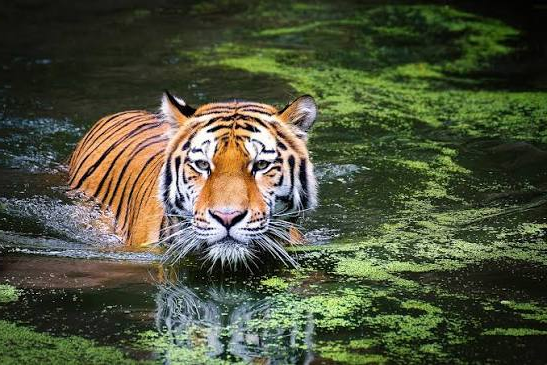

Saved transformed image to 'tiger_vertical_flip.jpg'
Transformed Image (Vertical Flip):


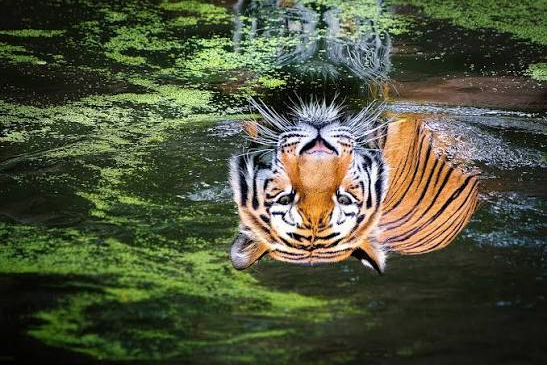

Saved transformed image to 'tiger_rotated_90deg_horizontal_flip.jpg'
Transformed Image (Rotated 90 degrees and Horizontally Flipped):


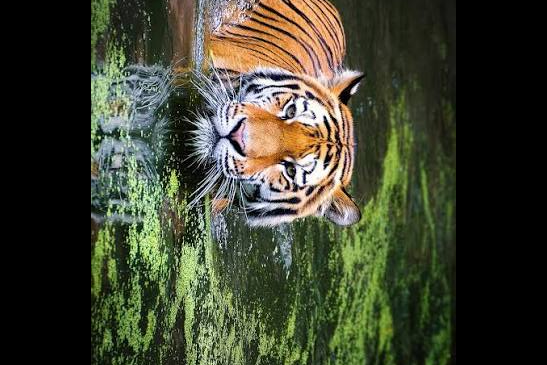

In [45]:
def rotate_and_flip_image(image, angle=0, flip_code=None, output_prefix='transformed_image'):
    transformed_img = image.copy()
    description = []

    if angle != 0:
        (h, w) = transformed_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        transformed_img = cv2.warpAffine(transformed_img, M, (w, h))
        description.append(f"rotated_{angle}deg")

    if flip_code is not None:
        transformed_img = cv2.flip(transformed_img, flip_code)
        if flip_code == 0:
            description.append("vertical_flip")
        elif flip_code > 0:
            description.append("horizontal_flip")
        else:
            description.append("both_flip")

    output_filename = f"{output_prefix}_{'_'.join(description)}.jpg" if description else f"{output_prefix}_original.jpg"

    cv2.imwrite(output_filename, transformed_img)
    print(f"Saved transformed image to '{output_filename}'")

    print(f"Transformed Image ({' '.join(description).replace('_', ' ').title() if description else 'Original'}):")
    cv2_imshow(transformed_img)


print("--- Original Image ---")
cv2_imshow(img)

rotate_and_flip_image(img, angle=90, output_prefix='tiger')


rotate_and_flip_image(img, angle=180, output_prefix='tiger')


rotate_and_flip_image(img, flip_code=1, output_prefix='tiger')


rotate_and_flip_image(img, flip_code=0, output_prefix='tiger')


(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M_rot = cv2.getRotationMatrix2D(center, 90, 1.0)
rotated_90_img = cv2.warpAffine(img, M_rot, (w, h))

rotated_90_flipped_img = cv2.flip(rotated_90_img, 1)

output_filename_combined = 'tiger_rotated_90deg_horizontal_flip.jpg'
cv2.imwrite(output_filename_combined, rotated_90_flipped_img)
print(f"Saved transformed image to '{output_filename_combined}'")
print("Transformed Image (Rotated 90 degrees and Horizontally Flipped):")
cv2_imshow(rotated_90_flipped_img)


### 10. Simple image metadata viewer that extracts EXIF data (if present) and pixel statistics.

In [46]:
from PIL import Image
from PIL.ExifTags import TAGS

def get_image_metadata(image_path):
    """
    Extracts and displays EXIF data and pixel statistics for an image.

    Args:
        image_path (str): The path to the image file.
    """
    print(f"\n--- Metadata for {os.path.basename(image_path)} ---")

    try:
        with Image.open(image_path) as pil_img:
            exif_data = pil_img._getexif()

            if exif_data:
                print("EXIF Data Found:")
                for tag_id, value in exif_data.items():
                    tag = TAGS.get(tag_id, tag_id)
                    print(f"  {tag}: {value}")
            else:
                print("No EXIF data found.")
    except Exception as e:
        print(f"Error reading EXIF data: {e}")

    try:
        cv_img = img

        if cv_img is None:
            print(f"Error: Could not load image at {image_path} for pixel statistics.")
            return

        if len(cv_img.shape) == 3:
            gray_cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
        else:
            gray_cv_img = cv_img

        print("\nPixel Statistics (Grayscale):")
        print(f"  Mean: {np.mean(gray_cv_img):.2f}")
        print(f"  Median: {np.median(gray_cv_img):.2f}")
        print(f"  Min: {np.min(gray_cv_img)}")
        print(f"  Max: {np.max(gray_cv_img)}")
        print(f"  Standard Deviation: {np.std(gray_cv_img):.2f}")

    except Exception as e:
        print(f"Error calculating pixel statistics: {e}")

get_image_metadata(image_path)


--- Metadata for tiger.jpeg ---
No EXIF data found.

Pixel Statistics (Grayscale):
  Mean: 79.52
  Median: 60.00
  Min: 0
  Max: 255
  Standard Deviation: 58.67


####